# 01b — Exploratory Data Analysis

## Goals
- Understand demand distribution across products and stores
- Identify zero-sales patterns — true zero demand vs likely stockouts
- Analyze temporal patterns — day of week, monthly, annual seasonality
- Measure impact of holidays and SNAP days on demand
- Identify anomalies — impossible values, outlier products, data gaps
- Assess store similarity — are CA stores interchangeable or distinct?

## Why EDA after ingestion
Data is already in Parquet — fast selective reads mean we can explore
efficiently without reloading raw CSVs. Findings here will be used to
validate or revise decisions made in notebooks 02 and 03.

## Scope
FOODS category, California stores (CA_1 — CA_4)
Same scope as demand forecasting notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
PARQUET_PATH = Path('../data/parquet')
REPORTS_PATH = Path('../reports')
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

# Load FOODS/CA data
print("Loading FOODS/CA data...")
df = pd.read_parquet(
    PARQUET_PATH / 'daily_sales.parquet',
    filters=[
        ('cat_id', '=', 'FOODS'),
        ('state_id', '=', 'CA')
    ]
)

# Reduce memory
df['units_sold'] = df['units_sold'].astype('int16')
df['wday']       = df['wday'].astype('int8')
df['month']      = df['month'].astype('int8')
df['year']       = df['year'].astype('int16')
df['snap_CA']    = df['snap_CA'].astype('int8')
df['date']       = pd.to_datetime(df['date'])

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique products: {df['item_id'].nunique()}")
print(f"Unique stores: {sorted(df['store_id'].unique())}")

Loading FOODS/CA data...
Shape: (10995924, 19)
Memory: 7199.1 MB
Date range: 2011-01-29 to 2016-04-24
Unique products: 1437
Unique stores: ['CA_1', 'CA_2', 'CA_3', 'CA_4']


In [3]:
# Reduce memory — drop unused columns
df = df.drop(columns=['id', 'wm_yr_wk', 'snap_TX', 'snap_WI',
                       'event_type_1', 'state_id', 'd'])

# Convert categoricals
for col in ['item_id', 'dept_id', 'cat_id', 'store_id', 'weekday', 'event_name_1']:
    df[col] = df[col].astype('category')

print(f"Memory after reduction: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")
print(f"Columns: {df.columns.tolist()}")

Memory after reduction: 230.8 MB
Columns: ['item_id', 'dept_id', 'cat_id', 'store_id', 'units_sold', 'date', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'snap_CA']


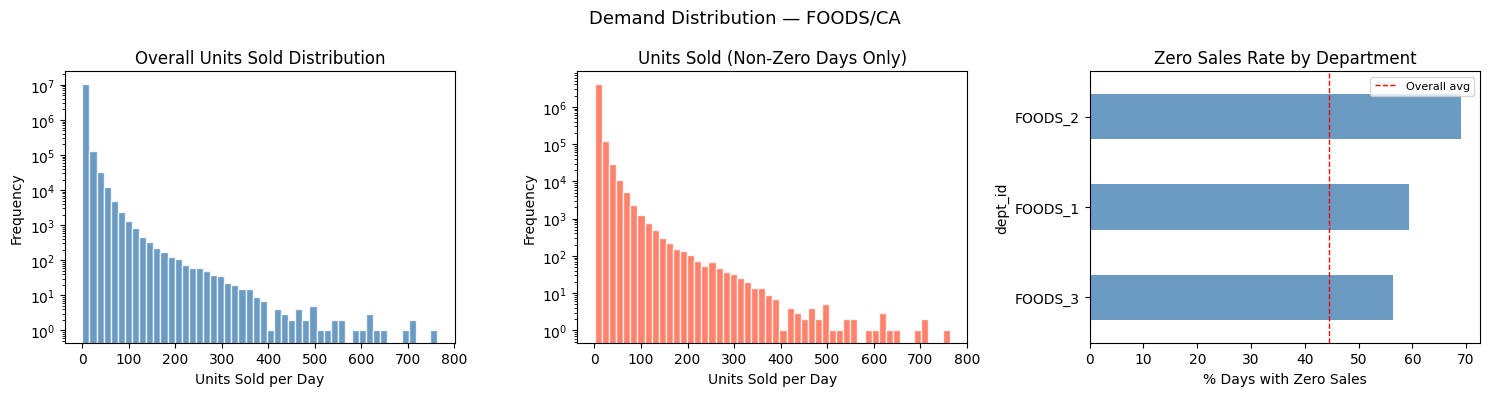

Overall zero sales rate: 60.4%
Max units sold in a day: 763
99th percentile:         21 units
Mean (non-zero days):    4.41 units


In [5]:
# 1. Demand distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Overall units sold distribution
ax = axes[0]
ax.hist(df['units_sold'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Overall Units Sold Distribution')
ax.set_xlabel('Units Sold per Day')
ax.set_ylabel('Frequency')
ax.set_yscale('log')

# Distribution excluding zeros
ax = axes[1]
nonzero = df[df['units_sold'] > 0]['units_sold']
ax.hist(nonzero, bins=50, color='tomato', alpha=0.8, edgecolor='white')
ax.set_title('Units Sold (Non-Zero Days Only)')
ax.set_xlabel('Units Sold per Day')
ax.set_ylabel('Frequency')
ax.set_yscale('log')

# Zero sales rate by department
ax = axes[2]
zero_rate = df.groupby('dept_id', observed=True).apply(
    lambda x: (x['units_sold'] == 0).mean() * 100
).sort_values(ascending=True)
zero_rate.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Zero Sales Rate by Department')
ax.set_xlabel('% Days with Zero Sales')
ax.axvline(44.5, color='red', linestyle='--', linewidth=1, label='Overall avg')
ax.legend(fontsize=8)

plt.suptitle('Demand Distribution — FOODS/CA', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_01_demand_distribution.png', dpi=150)
plt.show()

print(f"Overall zero sales rate: {(df['units_sold']==0).mean()*100:.1f}%")
print(f"Max units sold in a day: {df['units_sold'].max()}")
print(f"99th percentile:         {df['units_sold'].quantile(0.99):.0f} units")
print(f"Mean (non-zero days):    {df[df['units_sold']>0]['units_sold'].mean():.2f} units")

In [6]:
# Investigate extreme demand days
print("Top 20 highest sales days:")
top_sales = df.nlargest(20, 'units_sold')[
    ['item_id', 'store_id', 'date', 'units_sold', 'event_name_1', 'snap_CA']
]
print(top_sales.to_string(index=False))

Top 20 highest sales days:
    item_id store_id       date  units_sold event_name_1  snap_CA
FOODS_3_090     CA_3 2013-09-14         763         none        0
FOODS_3_090     CA_3 2013-08-23         709         none        0
FOODS_3_090     CA_3 2013-09-13         709         none        0
FOODS_3_090     CA_3 2011-12-31         693         none        0
FOODS_3_785     CA_1 2012-06-22         648         none        0
FOODS_3_090     CA_3 2011-12-23         633         none        0
FOODS_3_090     CA_3 2013-09-11         620         none        0
FOODS_3_090     CA_3 2011-12-24         619         none        0
FOODS_3_090     CA_3 2013-09-12         613         none        0
FOODS_3_090     CA_1 2013-09-01         599         none        1
FOODS_3_090     CA_3 2011-12-30         585         none        0
FOODS_3_090     CA_3 2011-11-23         561         none        0
FOODS_3_090     CA_3 2013-09-16         554         none        0
FOODS_3_090     CA_3 2012-12-24         546      

In [7]:
# Check if September 2013 spikes coincide with price changes for FOODS_3_090
prices = pd.read_parquet(PARQUET_PATH / 'sell_prices.parquet')
prices['date'] = pd.to_datetime(prices['date'])

product_prices = prices[
    (prices['item_id'] == 'FOODS_3_090') &
    (prices['store_id'] == 'CA_3') &
    (prices['date'].dt.year == 2013)
].sort_values('date')

print("FOODS_3_090 CA_3 prices in 2013:")
print(product_prices[['date', 'sell_price']].to_string(index=False))

FOODS_3_090 CA_3 prices in 2013:
      date  sell_price
2013-01-05        1.25
2013-01-12        1.25
2013-01-19        1.25
2013-01-26        1.38
2013-02-02        1.38
2013-02-09        1.38
2013-02-16        1.38
2013-02-23        1.38
2013-03-02        1.38
2013-03-09        1.38
2013-03-16        1.38
2013-03-23        1.38
2013-03-30        1.38
2013-04-06        1.38
2013-04-13        1.38
2013-04-20        1.38
2013-04-27        1.38
2013-05-04        1.38
2013-05-11        1.38
2013-05-18        1.38
2013-05-25        1.38
2013-06-01        1.38
2013-06-08        1.38
2013-06-15        1.38
2013-06-22        1.38
2013-06-29        1.38
2013-07-06        1.38
2013-07-13        1.38
2013-07-20        1.38
2013-07-27        1.38
2013-08-03        1.38
2013-08-10        1.38
2013-08-17        1.00
2013-08-24        1.00
2013-08-31        1.00
2013-09-07        1.00
2013-09-14        1.00
2013-09-21        1.00
2013-09-28        1.38
2013-10-05        1.38
2013-10-12        1.38
2

## Finding 1: Price is the Primary Driver of Extreme Demand Spikes

**Evidence:**
- FOODS_3_090 at CA_3 dominates the top 20 sales days (18/20)
- September 2013 cluster (500-763 units/day) coincides exactly with a price drop from $1.38 → $1.00 (28% reduction)
- November 2013 cluster coincides with another $1.38 → $1.00 promotional period
- Holiday spikes (December, Thanksgiving) are real but smaller in magnitude than price promotions


- Price features were excluded from the forecasting model
- Model cannot predict promotional demand spikes — treats them as unexplained variance
- This directly inflates RMSE and will produce unrealistic simulation outcomes during promotions

**Recommended fix:**
- Join `sell_prices.parquet` to feature matrix in notebook 02
- Add `sell_price`, `price_change` (week-over-week), and `is_on_promotion` (price below rolling average) as features
- Expected to significantly reduce RMSE for high-velocity products



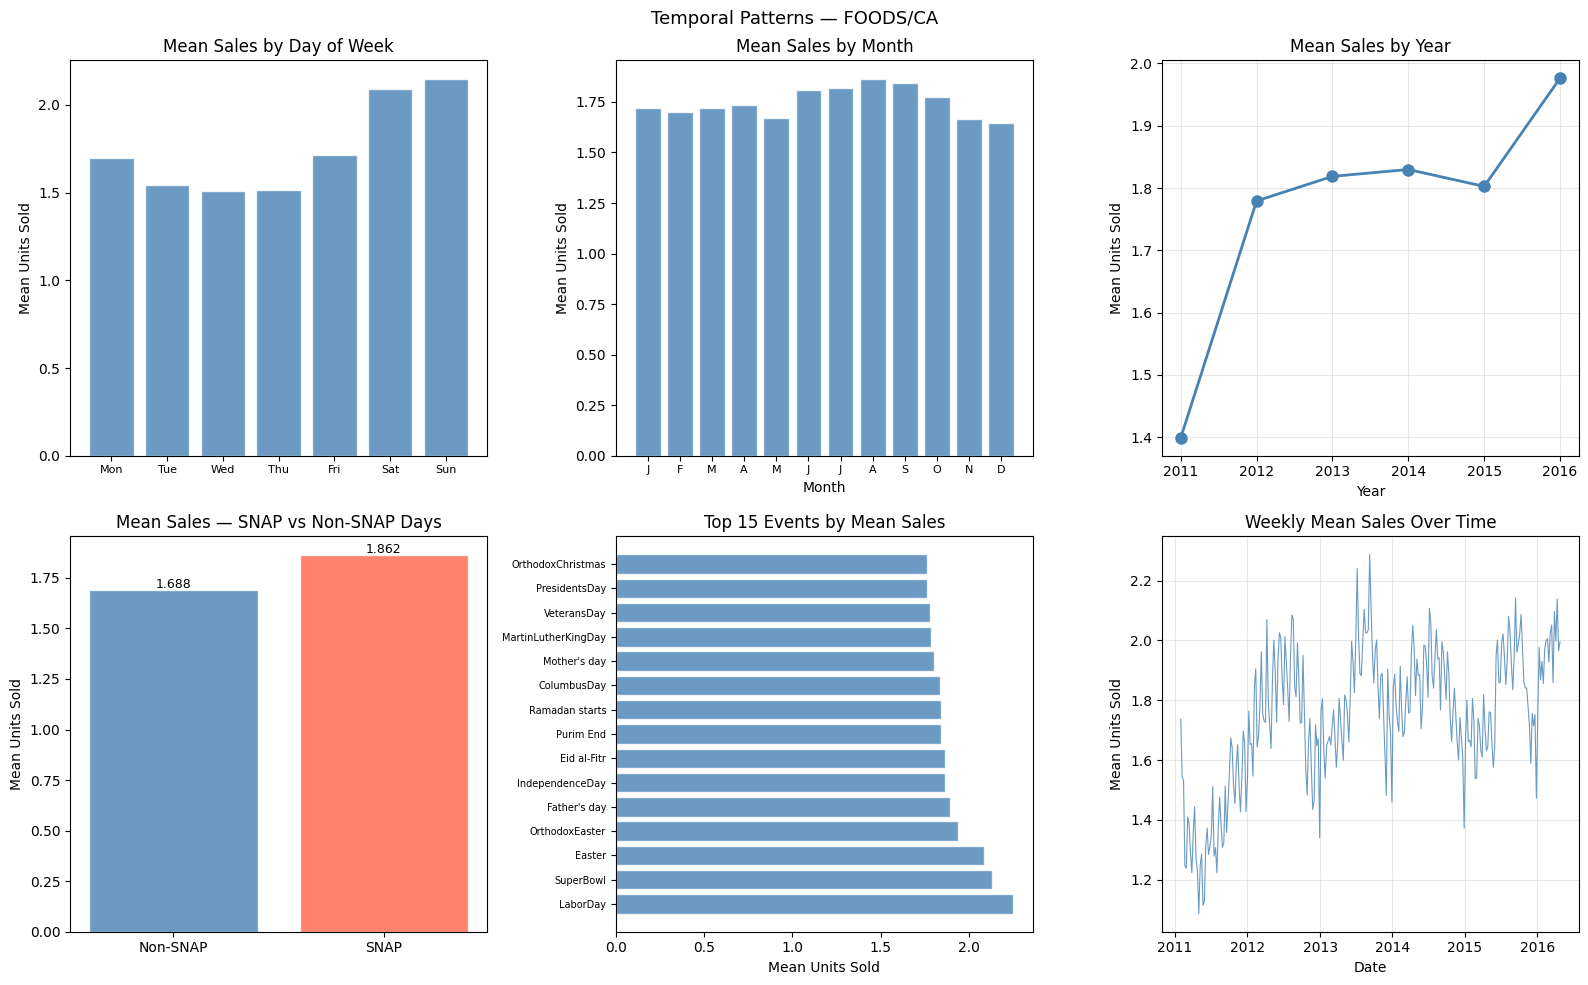

In [8]:
# 2. Temporal patterns
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Day of week
dow_sales = df.groupby('weekday', observed=True)['units_sold'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
axes[0,0].bar(range(7), dow_sales.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].set_xticks(range(7))
axes[0,0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], fontsize=8)
axes[0,0].set_title('Mean Sales by Day of Week')
axes[0,0].set_ylabel('Mean Units Sold')

# Monthly seasonality
monthly = df.groupby('month')['units_sold'].mean()
axes[0,1].bar(monthly.index, monthly.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Mean Sales by Month')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Mean Units Sold')
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=8)

# Annual trend
annual = df.groupby('year')['units_sold'].mean()
axes[0,2].plot(annual.index, annual.values, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0,2].set_title('Mean Sales by Year')
axes[0,2].set_xlabel('Year')
axes[0,2].set_ylabel('Mean Units Sold')
axes[0,2].grid(alpha=0.3)

# SNAP day impact
snap_sales = df.groupby('snap_CA')['units_sold'].mean()
axes[1,0].bar(['Non-SNAP', 'SNAP'], snap_sales.values, 
              color=['steelblue', 'tomato'], alpha=0.8, edgecolor='white')
axes[1,0].set_title('Mean Sales — SNAP vs Non-SNAP Days')
axes[1,0].set_ylabel('Mean Units Sold')
for i, v in enumerate(snap_sales.values):
    axes[1,0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# Holiday impact
holiday_sales = df.groupby('event_name_1', observed=True)['units_sold'].mean()\
    .sort_values(ascending=False).head(15)
axes[1,1].barh(range(len(holiday_sales)), holiday_sales.values, 
               color='steelblue', alpha=0.8, edgecolor='white')
axes[1,1].set_yticks(range(len(holiday_sales)))
axes[1,1].set_yticklabels(holiday_sales.index, fontsize=7)
axes[1,1].set_title('Top 15 Events by Mean Sales')
axes[1,1].set_xlabel('Mean Units Sold')

# Weekly sales trend over time
weekly = df.groupby(pd.Grouper(key='date', freq='W'))['units_sold'].mean()
axes[1,2].plot(weekly.index, weekly.values, color='steelblue', linewidth=0.8, alpha=0.8)
axes[1,2].set_title('Weekly Mean Sales Over Time')
axes[1,2].set_xlabel('Date')
axes[1,2].set_ylabel('Mean Units Sold')
axes[1,2].grid(alpha=0.3)

plt.suptitle('Temporal Patterns — FOODS/CA', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_02_temporal_patterns.png', dpi=150)
plt.show()

## Finding 2: Temporal Patterns

**Day of week:**
- Weekend effect is strong and consistent — Saturday/Sunday ~40% above mid-week
- `wday` correctly included as a feature — validates modeling decision

**Monthly seasonality:**
- Surprisingly weak at category level — December holiday effect is product-specific
- Monthly features have limited value for average product forecasting
- Recommendation: replace `month` with product-specific seasonal indices

**Annual trend:**
- Steady ~10% growth 2012-2016
- `year` feature captures this but won't extrapolate beyond training range
- Simulation should use 2014-2016 data to avoid incomplete 2011 distortion

**SNAP days:**
- 10.3% demand increase on SNAP benefit days — real and consistent signal
- `snap_CA` correctly included — validates modeling decision

**Events:**
- Event effects are small (1.8-2.2 units) compared to price promotions (700+ units)
- Calendar events are much less important than price changes as demand drivers
- Confirms price features are the highest priority addition to notebook 02

**Action:** 
- Add price features to notebook 02 (already noted in Finding 1)
- Consider restricting simulation to 2013-2016 to avoid incomplete 2011 data
- `month` feature may be droppable in favor of product-level seasonal indices

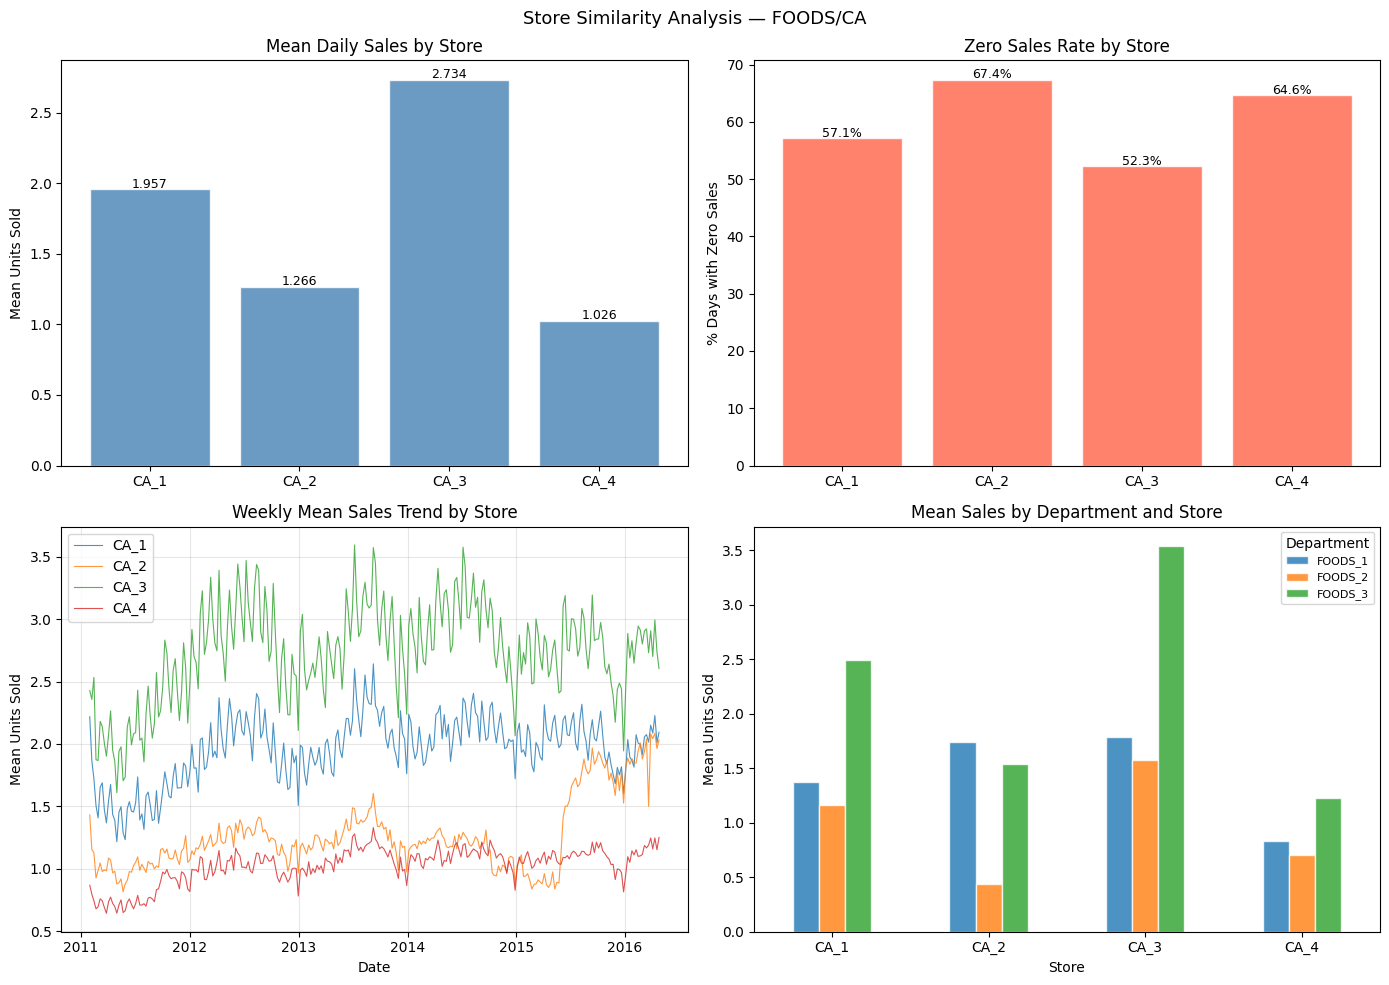


Store-level weekly sales correlation:
store_id   CA_1   CA_2   CA_3   CA_4
store_id                            
CA_1      1.000  0.367  0.901  0.869
CA_2      0.367  1.000  0.356  0.516
CA_3      0.901  0.356  1.000  0.830
CA_4      0.869  0.516  0.830  1.000


In [9]:
# 3. Store similarity analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean sales per store
store_sales = df.groupby('store_id', observed=True)['units_sold'].mean()
axes[0,0].bar(store_sales.index, store_sales.values, 
              color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].set_title('Mean Daily Sales by Store')
axes[0,0].set_ylabel('Mean Units Sold')
for i, v in enumerate(store_sales.values):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# Zero sales rate per store
zero_by_store = df.groupby('store_id', observed=True).apply(
    lambda x: (x['units_sold'] == 0).mean() * 100
)
axes[0,1].bar(zero_by_store.index, zero_by_store.values,
              color='tomato', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Zero Sales Rate by Store')
axes[0,1].set_ylabel('% Days with Zero Sales')
for i, v in enumerate(zero_by_store.values):
    axes[0,1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

# Weekly sales trend per store
weekly_store = df.groupby(
    ['store_id', pd.Grouper(key='date', freq='W')], observed=True
)['units_sold'].mean().reset_index()

for store in ['CA_1', 'CA_2', 'CA_3', 'CA_4']:
    store_data = weekly_store[weekly_store['store_id'] == store]
    axes[1,0].plot(store_data['date'], store_data['units_sold'], 
                   linewidth=0.8, alpha=0.8, label=store)
axes[1,0].set_title('Weekly Mean Sales Trend by Store')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Mean Units Sold')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Department mix per store
dept_store = df.groupby(
    ['store_id', 'dept_id'], observed=True
)['units_sold'].mean().unstack(fill_value=0)
dept_store.plot(kind='bar', ax=axes[1,1], alpha=0.8, edgecolor='white')
axes[1,1].set_title('Mean Sales by Department and Store')
axes[1,1].set_xlabel('Store')
axes[1,1].set_ylabel('Mean Units Sold')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='Department', fontsize=8)

plt.suptitle('Store Similarity Analysis — FOODS/CA', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_03_store_similarity.png', dpi=150)
plt.show()

# Correlation between stores
print("\nStore-level weekly sales correlation:")
store_pivot = weekly_store.pivot(index='date', columns='store_id', values='units_sold')
print(store_pivot.corr().round(3).to_string())

## Finding 3: CA Stores Are Not Interchangeable

**Key differences:**
- CA_3 sells 2.7x more than CA_4 — fundamentally different volume profiles
- CA_2 has 67.4% zero sales days vs CA_3's 52.3% — much more intermittent
- CA_2 correlation with other stores: 0.36-0.52 — behaves as a distinct market
- CA_3 FOODS_3 is dominated by high-velocity promotional products (FOODS_3_090)

**Impact on notebook 02:**
- Single model trained across all stores will underfit CA_3 and overfit CA_2
- `store_id` as a categorical feature partially captures this but not fully
- Recommendation: train separate models per store OR add store-level aggregate
  features (store mean sales, store zero rate) to give the model store context

**Impact on simulation (notebook 03):**
- Safety stock policies should be calibrated per store — a policy optimized for
  CA_3 will over-stock CA_2 and under-stock nothing
- Simulation results should be reported per store, not aggregated

**Impact on experiment design (notebook 04):**
- Randomization should be stratified by store — don't treat all stores equally
- CA_2's low-volume intermittent demand may make it unsuitable as a treatment unit

**Action:**
- Add store-level aggregate features to notebook 02
- Report simulation results per store in notebook 03
- Stratify randomization by store in notebook 04

In [11]:
# 4. Product-level anomaly detection
# Compute per-product statistics
print("Computing per-product statistics...")

product_stats = df.groupby(['item_id', 'store_id'], observed=True).agg(
    mean_sales    = ('units_sold', 'mean'),
    std_sales     = ('units_sold', 'std'),
    zero_rate     = ('units_sold', lambda x: (x==0).mean()),
    max_sales     = ('units_sold', 'max'),
    total_sales   = ('units_sold', 'sum'),
    n_days        = ('units_sold', 'count')
).reset_index()

product_stats['cv'] = product_stats['std_sales'] / (product_stats['mean_sales'] + 1e-9)

print(f"Total product-store combinations: {len(product_stats):,}")
print(f"\nProduct statistics summary:")
print(product_stats[['mean_sales', 'std_sales', 'zero_rate', 'cv']].describe().round(3).to_string())

Computing per-product statistics...
Total product-store combinations: 5,748

Product statistics summary:
       mean_sales  std_sales  zero_rate        cv
count    5748.000   5748.000   5748.000  5748.000
mean        1.746      2.098      0.604     2.096
std         3.837      3.170      0.242     1.239
min         0.006      0.091      0.002     0.253
25%         0.331      0.815      0.430     1.276
50%         0.763      1.306      0.630     1.734
75%         1.718      2.228      0.808     2.558
max       130.947    108.612      0.995    14.549


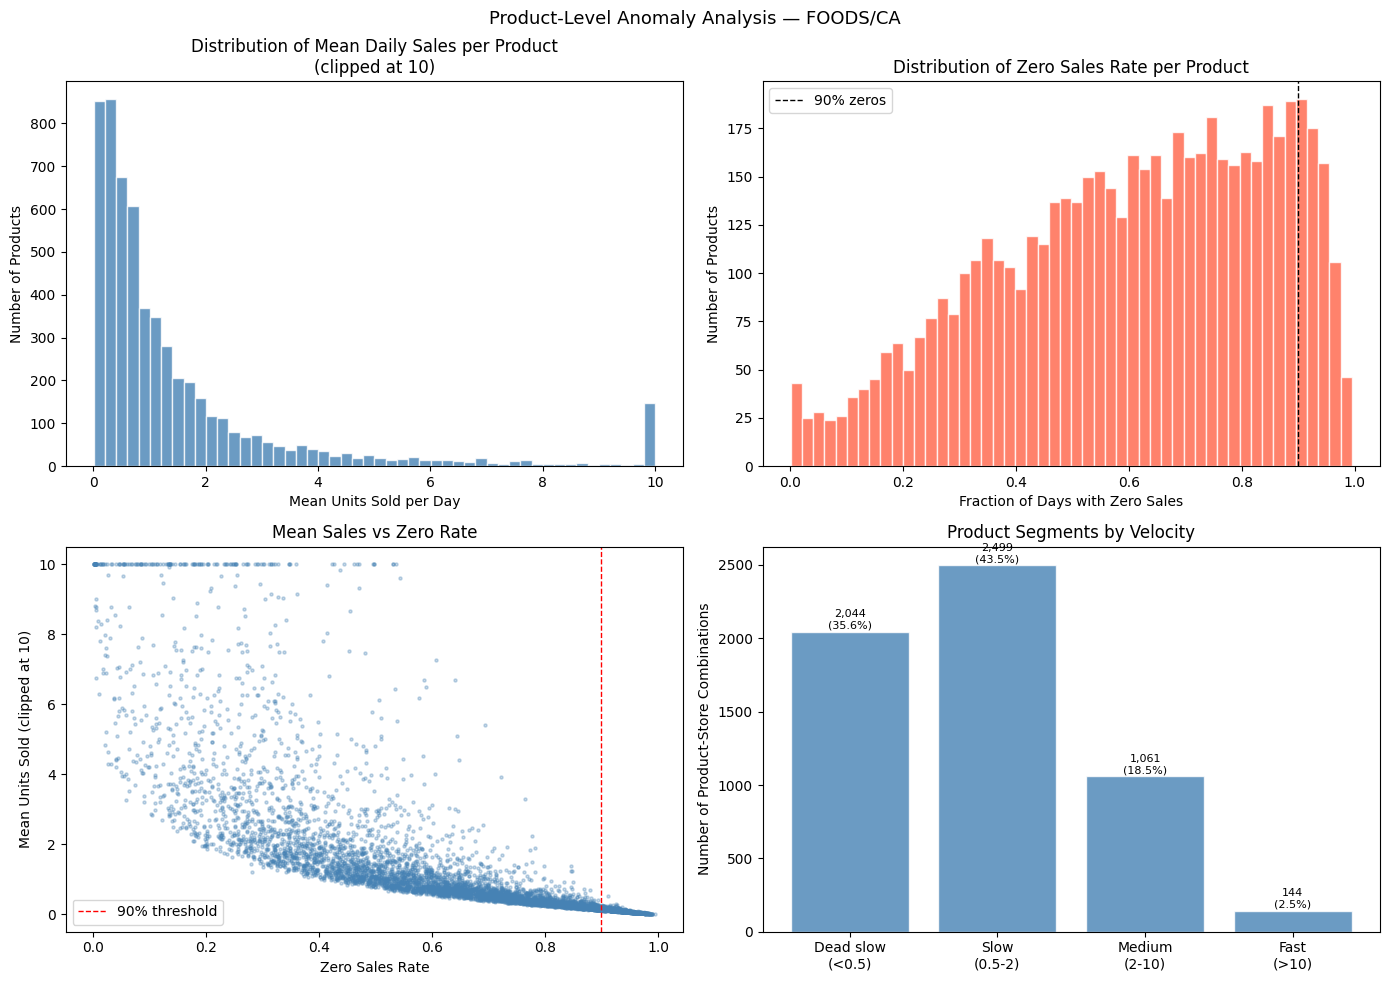


Dead products (>95% zeros): 183 (3.2%)
Extreme products (mean >20 units): 39

Extreme products:
    item_id store_id  mean_sales  max_sales  zero_rate
FOODS_3_090     CA_3  130.947203        763   0.187663
FOODS_3_586     CA_3   70.248824        151   0.002614
FOODS_3_090     CA_1   66.493988        599   0.245165
FOODS_3_120     CA_3   46.416623        276   0.346576
FOODS_3_586     CA_1   45.839519        133   0.003659
FOODS_3_252     CA_3   42.580240        138   0.003136
FOODS_3_541     CA_3   42.075797        306   0.134344
FOODS_3_635     CA_3   41.935180        355   0.124935
FOODS_3_252     CA_1   39.190277        147   0.003136
FOODS_3_808     CA_3   37.946158        329   0.145844
FOODS_3_587     CA_3   36.761108        154   0.092002
FOODS_3_586     CA_2   33.150026         84   0.001568
FOODS_3_120     CA_1   32.357031        205   0.348667
FOODS_3_555     CA_3   30.889702         76   0.002091
FOODS_3_252     CA_2   29.967590        141   0.003659
FOODS_3_090     CA_2   

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of mean sales per product
axes[0,0].hist(product_stats['mean_sales'].clip(upper=10), 
               bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].set_title('Distribution of Mean Daily Sales per Product\n(clipped at 10)')
axes[0,0].set_xlabel('Mean Units Sold per Day')
axes[0,0].set_ylabel('Number of Products')

# Distribution of zero rate
axes[0,1].hist(product_stats['zero_rate'], 
               bins=50, color='tomato', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Distribution of Zero Sales Rate per Product')
axes[0,1].set_xlabel('Fraction of Days with Zero Sales')
axes[0,1].set_ylabel('Number of Products')
axes[0,1].axvline(0.9, color='black', linestyle='--', linewidth=1, label='90% zeros')
axes[0,1].legend()

# Mean sales vs zero rate scatter
axes[1,0].scatter(product_stats['zero_rate'], 
                  product_stats['mean_sales'].clip(upper=10),
                  alpha=0.3, s=5, color='steelblue')
axes[1,0].set_title('Mean Sales vs Zero Rate')
axes[1,0].set_xlabel('Zero Sales Rate')
axes[1,0].set_ylabel('Mean Units Sold (clipped at 10)')
axes[1,0].axvline(0.9, color='red', linestyle='--', linewidth=1, label='90% threshold')
axes[1,0].legend()

# Product segments by velocity
product_stats['segment'] = pd.cut(
    product_stats['mean_sales'],
    bins=[0, 0.5, 2, 10, 200],
    labels=['Dead slow\n(<0.5)', 'Slow\n(0.5-2)', 'Medium\n(2-10)', 'Fast\n(>10)']
)
segment_counts = product_stats['segment'].value_counts().sort_index()
axes[1,1].bar(segment_counts.index, segment_counts.values,
              color='steelblue', alpha=0.8, edgecolor='white')
axes[1,1].set_title('Product Segments by Velocity')
axes[1,1].set_ylabel('Number of Product-Store Combinations')
for i, v in enumerate(segment_counts.values):
    axes[1,1].text(i, v + 20, f'{v:,}\n({v/len(product_stats)*100:.1f}%)', 
                   ha='center', fontsize=8)

plt.suptitle('Product-Level Anomaly Analysis — FOODS/CA', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_04_product_anomalies.png', dpi=150)
plt.show()

# Flag problematic products
dead_products = product_stats[product_stats['zero_rate'] > 0.95]
extreme_products = product_stats[product_stats['mean_sales'] > 20]

print(f"\nDead products (>95% zeros): {len(dead_products):,} ({len(dead_products)/len(product_stats)*100:.1f}%)")
print(f"Extreme products (mean >20 units): {len(extreme_products):,}")
print(f"\nExtreme products:")
print(extreme_products[['item_id', 'store_id', 'mean_sales', 'max_sales', 'zero_rate']]\
      .sort_values('mean_sales', ascending=False).to_string(index=False))

## Finding 4: Product Catalog Has Two Distinct Populations

**Segment breakdown (5,748 product-store combinations):**
| Segment | Count | % | Mean Sales | Implication |
|---|---|---|---|---|
| Dead slow (<0.5/day) | 2,044 | 35.6% | ~0.2 | Exclude from simulation |
| Slow (0.5-2/day) | 2,499 | 43.5% | ~1.0 | Standard inventory model |
| Medium (2-10/day) | 1,061 | 18.5% | ~4.0 | Standard inventory model |
| Fast (>10/day) | 144 | 2.5% | ~35 | Price-sensitive, needs special handling |

**Dead products:**
- 183 product-store combinations have >95% zero sales days
- Safety stock policy is irrelevant for these products
- Must be excluded from simulation to avoid meaningless results

**Extreme products:**
- 39 combinations with mean >20 units/day — almost all FOODS_3 at CA_3
- FOODS_3_586 sells on 99.7% of days — near-perfect availability
- FOODS_3_090 is price-sensitive (Finding 1) — drives most of the extreme variance
- These 39 combinations likely represent bulk staples (water, soda, bread)

**Impact on notebook 02:**
- Single model treats all products the same — suboptimal
- Fast movers need price features (Finding 1) — their spikes are promotion-driven
- Dead slow products inflate zero rate and drag down model performance
- Recommendation: train separate models per segment OR add segment as a feature

**Impact on simulation (notebook 03):**
- Exclude dead products (zero_rate > 0.95) from simulation
- Cap extreme product demand at 99th percentile during simulation
  to prevent unrealistic inventory requirements
- Report results separately by segment — a policy that works for fast movers
  may be irrelevant for slow movers

**Impact on experiment design (notebook 04):**
- Stratify randomization by segment — don't randomize across segments
- Primary analysis on slow + medium segments (79% of catalog)
- Separate analysis for fast movers — different policy may be optimal

**Action:**
- Add `segment` as a feature in notebook 02
- Filter dead products before simulation in notebook 03
- Stratify by segment in experiment design notebook 04

In [13]:
# 5. Missingness analysis
print("=== MISSINGNESS ANALYSIS ===\n")

# Check for null values in main dataframe
print("Null values per column:")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No null values found")

# Check for missing date gaps per product
print("\nChecking for date gaps per product-store combination...")
expected_days = (df['date'].max() - df['date'].min()).days + 1
print(f"Expected days in range: {expected_days}")

date_counts = df.groupby(['item_id', 'store_id'], observed=True)['date'].count()
print(f"Products with full date coverage: {(date_counts == expected_days).sum():,}")
print(f"Products with missing dates:      {(date_counts < expected_days).sum():,}")
print(f"\nDate count distribution:")
print(date_counts.describe().round(0).to_string())

# Products that appear late in the dataset (launched after start)
late_starts = df.groupby(['item_id', 'store_id'], observed=True)['date'].min()
early_date = df['date'].min()
late_products = late_starts[late_starts > early_date + pd.Timedelta(days=90)]
print(f"\nProducts launched more than 90 days after dataset start: {len(late_products):,}")
print(f"  ({len(late_products)/len(date_counts)*100:.1f}% of catalog)")

# Products that disappear before end of dataset
early_ends = df.groupby(['item_id', 'store_id'], observed=True)['date'].max()
end_date = df['date'].max()
discontinued = early_ends[early_ends < end_date - pd.Timedelta(days=90)]
print(f"\nProducts discontinued more than 90 days before dataset end: {len(discontinued):,}")
print(f"  ({len(discontinued)/len(date_counts)*100:.1f}% of catalog)")

=== MISSINGNESS ANALYSIS ===

Null values per column:
No null values found

Checking for date gaps per product-store combination...
Expected days in range: 1913
Products with full date coverage: 5,748
Products with missing dates:      0

Date count distribution:
count    5748.0
mean     1913.0
std         0.0
min      1913.0
25%      1913.0
50%      1913.0
75%      1913.0
max      1913.0

Products launched more than 90 days after dataset start: 0
  (0.0% of catalog)

Products discontinued more than 90 days before dataset end: 0
  (0.0% of catalog)


## Finding 5: Data Completeness — No Missingness

- Zero null values across all columns
- All 5,748 product-store combinations have exactly 1,913 days of coverage
- No products launched late or discontinued early
- No date gaps within any product's history

**Implication:** Zero sales days are true zeros — confirmed demand signal,
not missing data. The 60.4% zero rate reflects genuine intermittent demand,
not data quality issues. This validates our modeling approach.

**No data cleaning required for missingness.**

In [14]:
# 6. Stockout proxy analysis
# Zero sales days are ambiguous — true zero demand OR shelf was empty
# We can identify likely stockouts by looking for zero sales days
# surrounded by non-zero sales days for products with consistent demand

print("=== STOCKOUT PROXY ANALYSIS ===\n")

# Focus on fast and medium movers — low velocity products have too many
# true zero demand days to identify stockouts reliably
fast_medium = product_stats[product_stats['mean_sales'] >= 2]['item_id'].unique()
df_fm = df[df['item_id'].isin(fast_medium)].copy()

print(f"Fast + medium mover product-store combinations: {df_fm.groupby(['item_id','store_id'], observed=True).ngroups:,}")

# Sort by product, store, date
df_fm = df_fm.sort_values(['item_id', 'store_id', 'date']).reset_index(drop=True)

# Identify likely stockouts:
# A zero sales day is a likely stockout if:
# - The product sold something in the 3 days before
# - The product sold something in the 3 days after
# - The product's overall zero rate is below 50%
group = df_fm.groupby(['item_id', 'store_id'], observed=True)['units_sold']

df_fm['prev_3_max'] = group.transform(lambda x: x.shift(1).rolling(3, min_periods=1).max())
df_fm['next_3_max'] = group.transform(lambda x: x.shift(-1).rolling(3, min_periods=1).max())

# Join zero rates
df_fm = df_fm.merge(
    product_stats[['item_id', 'store_id', 'zero_rate']],
    on=['item_id', 'store_id'],
    how='left'
)

df_fm['likely_stockout'] = (
    (df_fm['units_sold'] == 0) &
    (df_fm['prev_3_max'] > 0) &
    (df_fm['next_3_max'] > 0) &
    (df_fm['zero_rate'] < 0.5)
)

# Stockout statistics
total_days = len(df_fm)
stockout_days = df_fm['likely_stockout'].sum()
zero_days = (df_fm['units_sold'] == 0).sum()

print(f"Total days analyzed: {total_days:,}")
print(f"Zero sales days: {zero_days:,} ({zero_days/total_days*100:.1f}%)")
print(f"Likely stockout days: {stockout_days:,} ({stockout_days/total_days*100:.1f}%)")
print(f"Stockouts as % of zero days: {stockout_days/zero_days*100:.1f}%")

# Stockout rate by store
print("\nStockout rate by store:")
store_stockout = df_fm.groupby('store_id', observed=True).agg(
    stockout_rate=('likely_stockout', 'mean'),
    zero_rate=('units_sold', lambda x: (x==0).mean())
).round(4) * 100
print(store_stockout.to_string())

# Stockout rate by department
print("\nStockout rate by department:")
dept_stockout = df_fm.groupby('dept_id', observed=True).agg(
    stockout_rate=('likely_stockout', 'mean'),
    zero_rate=('units_sold', lambda x: (x==0).mean())
).round(4) * 100
print(dept_stockout.to_string())

=== STOCKOUT PROXY ANALYSIS ===

Fast + medium mover product-store combinations: 1,972
Total days analyzed: 3,772,436
Zero sales days: 1,425,813 (37.8%)
Likely stockout days: 317,265 (8.4%)
Stockouts as % of zero days: 22.3%

Stockout rate by store:
          stockout_rate  zero_rate
store_id                          
CA_1               8.41      34.40
CA_2               7.32      45.79
CA_3               8.46      27.75
CA_4               9.46      43.24

Stockout rate by department:
         stockout_rate  zero_rate
dept_id                          
FOODS_1           8.38      40.59
FOODS_2           9.66      42.53
FOODS_3           8.11      36.01


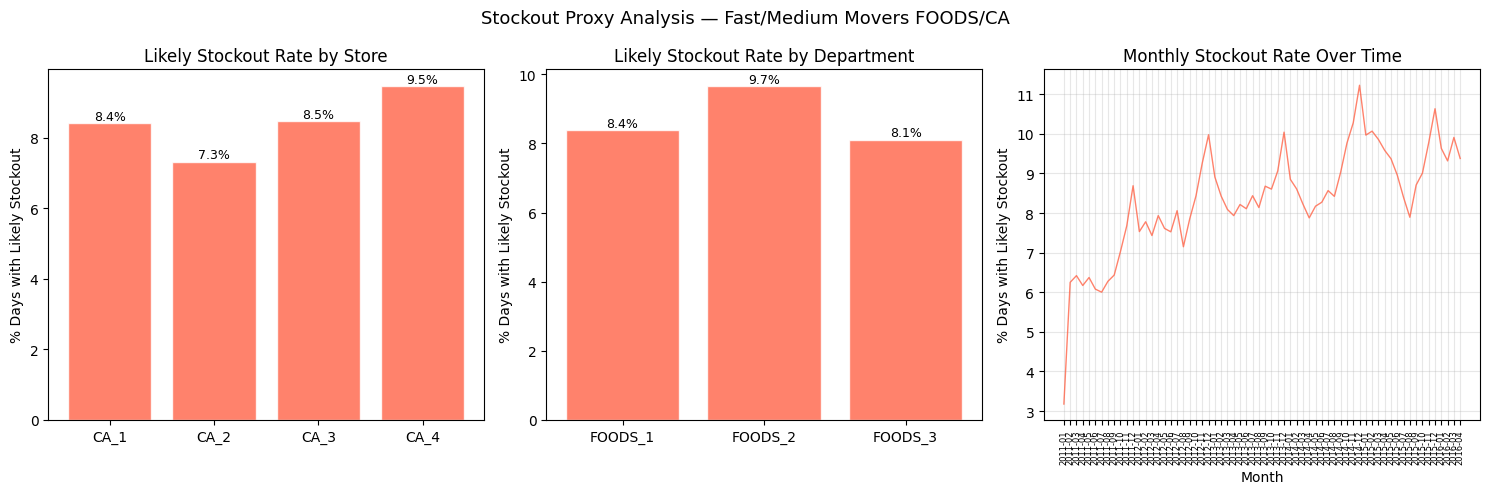

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Stockout rate by store
axes[0].bar(store_stockout.index, store_stockout['stockout_rate'],
            color='tomato', alpha=0.8, edgecolor='white')
axes[0].set_title('Likely Stockout Rate by Store')
axes[0].set_ylabel('% Days with Likely Stockout')
for i, v in enumerate(store_stockout['stockout_rate']):
    axes[0].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

# Stockout rate by department  
axes[1].bar(dept_stockout.index, dept_stockout['stockout_rate'],
            color='tomato', alpha=0.8, edgecolor='white')
axes[1].set_title('Likely Stockout Rate by Department')
axes[1].set_ylabel('% Days with Likely Stockout')
for i, v in enumerate(dept_stockout['stockout_rate']):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

# Stockout rate over time
df_fm['year_month'] = df_fm['date'].dt.to_period('M')
monthly_stockout = df_fm.groupby('year_month')['likely_stockout'].mean() * 100
axes[2].plot(monthly_stockout.index.astype(str), monthly_stockout.values,
             color='tomato', linewidth=1, alpha=0.8)
axes[2].set_title('Monthly Stockout Rate Over Time')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('% Days with Likely Stockout')
axes[2].tick_params(axis='x', rotation=90, labelsize=6)
axes[2].grid(alpha=0.3)

plt.suptitle('Stockout Proxy Analysis — Fast/Medium Movers FOODS/CA', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_05_stockout_analysis.png', dpi=150)
plt.show()

## Finding 6: Stockout Proxy Analysis

**Baseline stockout rate (fast/medium movers):**
- 8.4% of all days have likely stockouts
- 22.3% of zero-sales days are likely stockouts rather than true zero demand

**By store:**
- CA_4 worst: 9.5% — low volume store that still runs out of stock frequently
- CA_2 best: 7.3% — low demand means less stockout pressure
- CA_3: 8.5% — high velocity creates stockout pressure despite good operations

**By department:**
- FOODS_2 worst: 9.7% — most supply-constrained department
- FOODS_3 best: 8.1% — better managed despite highest velocity

**Temporal trend — critical finding:**
- Stockout rate increases from ~3-6% in 2011 to ~9-11% by 2015-2016
- Demand growing faster than inventory replenishment keeping up
- **This means our simulation must account for trend** — a static safety
  stock policy evaluated on 2011 data will look better than one evaluated
  on 2016 data purely because baseline conditions worsened over time

**Simulation calibration target:**
- Baseline stockout rate: ~8.4% for fast/medium movers
- If simulation cannot reproduce ~8% stockout rate with current policy,
  simulation parameters need recalibration before running experiments

**Action:**
- Use 2013-2016 data for simulation — avoids incomplete 2011 and captures
  the worsening trend period where safety stock decisions matter most
- Report stockout rates relative to store/department baseline,
  not absolute numbers

In [16]:
# EDA Summary — print all findings and recommended actions
print("=" * 65)
print("EDA SUMMARY — FOODS/CA SUPPLY CHAIN POLICY LAB")
print("=" * 65)

print("""
DATASET
-------
- 10,995,924 rows (FOODS category, CA stores, 2011-2016)
- 5,748 product-store combinations
- 1,913 days of coverage — no missingness, no gaps
- 60.4% overall zero sales rate

FINDING 1: Price is the primary demand driver
- FOODS_3_090 spikes from ~10 to 700+ units on promotion days
- 28% price drop ($1.38 → $1.00) drives extreme demand
- Model trained without price features — major gap
ACTION: Add sell_price, price_change, is_on_promotion to notebook 02

FINDING 2: Temporal patterns
- Weekend effect strong (+40% Saturday/Sunday)
- Monthly seasonality weak at category level
- SNAP days drive +10.3% demand increase
- Annual growth trend ~10% over dataset period
ACTION: Keep wday and snap_CA features, consider dropping month

FINDING 3: CA stores are not interchangeable
- CA_3 sells 2.7x more than CA_4
- CA_2 correlation with other stores: 0.36 — distinct market
- CA_3 dominated by high-velocity promotional products
ACTION: Add store-level aggregate features, stratify by store in
        experiment design, report simulation results per store

FINDING 4: Two distinct product populations
- 35.6% dead slow (<0.5 units/day) — exclude from simulation
- 2.5% fast movers (>10 units/day) — price-sensitive, needs
  separate handling
- 183 dead products (>95% zeros) — exclude entirely
ACTION: Filter dead products before simulation, add segment
        feature to notebook 02, stratify by segment in experiment

FINDING 5: No missingness
- Zero null values, perfect date coverage
- Zero sales days are genuine demand signal, not missing data
ACTION: None required

FINDING 6: Stockout proxy analysis
- 8.4% baseline stockout rate for fast/medium movers
- Stockout rate worsening over time (3-6% in 2011 → 9-11% in 2016)
- FOODS_2 most supply-constrained (9.7%)
- CA_4 most stockout-prone store (9.5%)
ACTION: Use 2013-2016 for simulation, calibrate to ~8.4% baseline,
        report results relative to store/department baseline
""")

print("=" * 65)
print("NOTEBOOK 02 REVISIONS REQUIRED")
print("=" * 65)
print("""
1. Add price features — sell_price, price_change, is_on_promotion
2. Add store-level aggregate features — store mean sales, store zero rate
3. Add product segment as a feature
4. Drop or deprioritize month feature
5. Consider training separate models per store
6. Restrict training data to 2013-2016
""")

print("=" * 65)
print("NOTEBOOK 03 CONSTRAINTS")
print("=" * 65)
print("""
1. Exclude dead products (zero_rate > 0.95) from simulation
2. Use 2013-2016 data only
3. Calibrate to ~8.4% baseline stockout rate
4. Report results per store and per segment
5. Cap extreme demand at 99th percentile during simulation
""")

EDA SUMMARY — FOODS/CA SUPPLY CHAIN POLICY LAB

DATASET
-------
- 10,995,924 rows (FOODS category, CA stores, 2011-2016)
- 5,748 product-store combinations
- 1,913 days of coverage — no missingness, no gaps
- 60.4% overall zero sales rate

FINDING 1: Price is the primary demand driver
- FOODS_3_090 spikes from ~10 to 700+ units on promotion days
- 28% price drop ($1.38 → $1.00) drives extreme demand
- Model trained without price features — major gap
ACTION: Add sell_price, price_change, is_on_promotion to notebook 02

FINDING 2: Temporal patterns
- Weekend effect strong (+40% Saturday/Sunday)
- Monthly seasonality weak at category level
- SNAP days drive +10.3% demand increase
- Annual growth trend ~10% over dataset period
ACTION: Keep wday and snap_CA features, consider dropping month

FINDING 3: CA stores are not interchangeable
- CA_3 sells 2.7x more than CA_4
- CA_2 correlation with other stores: 0.36 — distinct market
- CA_3 dominated by high-velocity promotional products
ACTION: 

## EDA Complete

Six findings documented. Two notebooks require revision before proceeding.

### Revised pipeline order
1. ✅ `01_data_ingestion.ipynb` — complete, no changes needed
2. ✅ `01b_eda.ipynb` — complete
3. 🔄 `02_demand_forecasting.ipynb` — **rewrite required** (price features,
   store aggregates, segment feature, 2013-2016 scope)
4. `03_inventory_simulation.ipynb` — pending (apply EDA constraints)
5. `04_experiment_design.ipynb` — pending (stratify by store and segment)
6. `05_causal_inference.ipynb` — pending
7. `06_policy_recommendation.ipynb` — pending

### Reports saved
- `reports/eda_01_demand_distribution.png`
- `reports/eda_02_temporal_patterns.png`
- `reports/eda_03_store_similarity.png`
- `reports/eda_04_product_anomalies.png`
- `reports/eda_05_stockout_analysis.png`